<a href="https://colab.research.google.com/github/hlmonge/HenryMonge_Reciclaje/blob/main/Computacion_Nube_Reciclaje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 1 Sistema con IA para clasificacion de Reciclaje



Entrenar un modelo con las clases:
- cardboard
- glass
- metal
- paper
- plastic
- trash

Al final guardara el modelo y las clases para usarlo en streamlit.




# Paso 1 Instalar Dependencias

In [26]:
!pip install tensorflow numpy pillow matplotlib

In [27]:
!pip install kagglehub

In [28]:
from kagglehub import dataset_download
dataset_path = dataset_download("saumyamohandas/garbage-classification-image-dataset")
print("Ruta del datasetL", dataset_path)

Using Colab cache for faster access to the 'garbage-classification-image-dataset' dataset.
Ruta del datasetL /kaggle/input/garbage-classification-image-dataset


In [29]:
import os
for folder in os.listdir(dataset_path):
  print(folder)

dataset


In [30]:
import tensorflow as tf
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(244,244),
    batch_size=32
)
class_names=train_ds.class_names
print(class_names)

Found 2972 files belonging to 1 classes.
['dataset']


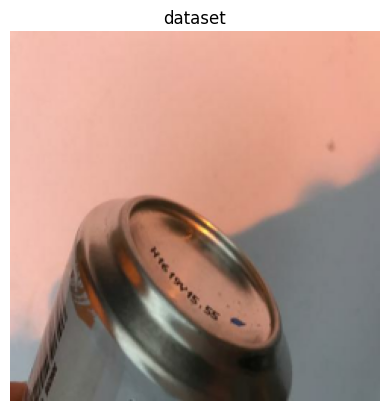

In [31]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):

    plt.imshow(images[0].numpy().astype("uint8"))

    plt.title(class_names[labels[0]])

    plt.axis("off")

## Paso 2 Importar librerias

In [32]:
import json

import os

from pathlib import Path

import matplotlib.pyplot as plt

import numpy as np

import tensorflow as tf

from PIL import Image

## Paso 3 Ajustar la ruta del dataset

La carpeta del dataset debe verse asi:

```
garbage-classification/
    cardboard/
    glass/
    metal/
    paper/
    plastic/
    trash/
```


## Paso Cargar imagenes

In [33]:
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

# Define DATA_DIR el path de kagglehub download

DATA_DIR = os.path.join(dataset_path, 'dataset')



train_data_path = os.path.join(DATA_DIR, 'Training')

val_data_path = os.path.join(DATA_DIR, 'Testing')

train_ds = tf.keras.utils.image_dataset_from_directory(

    train_data_path,

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

)

val_ds = tf.keras.utils.image_dataset_from_directory(

    val_data_path,

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

)

class_names = train_ds.class_names

print("Clases detectadas:", class_names)

Found 2508 files belonging to 6 classes.
Found 464 files belonging to 6 classes.
Clases detectadas: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Paso 5 Ver algunas imagenes

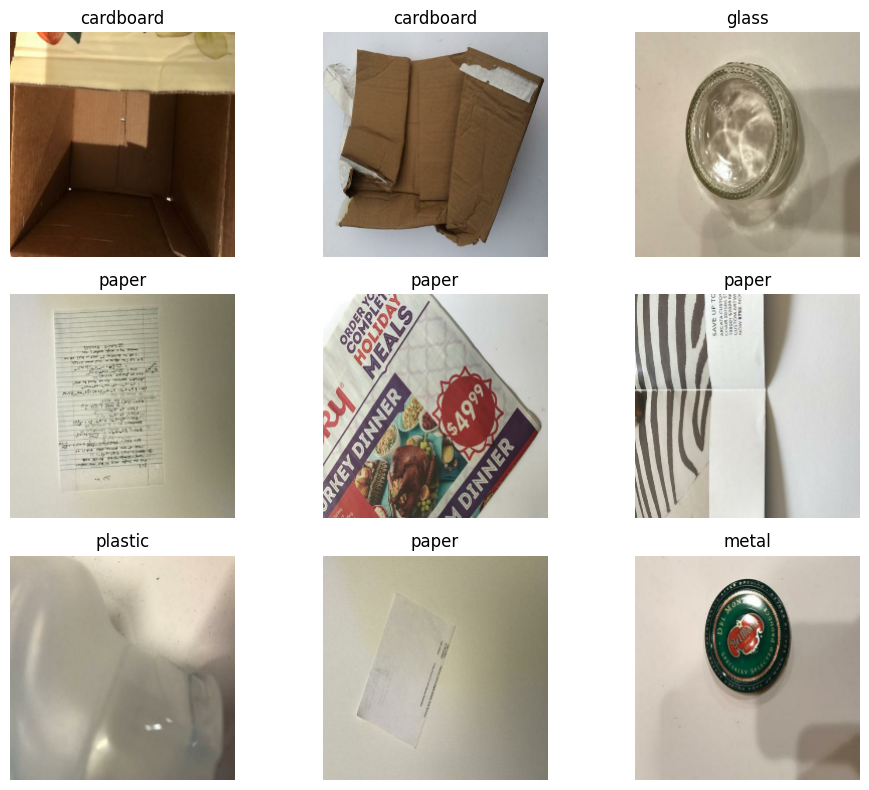

In [34]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):

    for i in range(min(9, len(images))):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

## Paso 6 Prepara el dataset

In [35]:
AUTOTUNE = tf.data.AUTOTUNE

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)

val_ds = val_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)

## Paso 7 Crear el modelo en base a MobileNetV2

In [36]:
#Crear el modelo MobileNetV

base_model = tf.keras.applications.MobileNetV2(

    input_shape=IMG_SIZE + (3,),

    include_top=False,

    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

x = base_model(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Paso 8 Repasar una vez EPOCH = 1

In [37]:
EPOCHS = 1

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
)
]
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.5873 - loss: 1.1265 - val_accuracy: 0.7522 - val_loss: 0.7827


## Paso 9 Evauar

In [38]:
loss, acc = model.evaluate(val_ds, verbose=0)
print(f"loss: {loss:.4f}")
print(f"Accuracy: {acc:.4f}")

loss: 0.7827
Accuracy: 0.7522


## Paso 10 Guardar el Modelo

In [40]:
OUTPUT_DIR = Path("modelo_reciclaje_mobilenet")

OUTPUT_DIR.mkdir(exist_ok=True)

model.save(OUTPUT_DIR / "waste_mobilenet.h5")

#(HDF5- Hierarchical Data Format version 5)

model.save(OUTPUT_DIR / "waste_mobilenet.keras")

with open(OUTPUT_DIR / "class_names.json", "w", encoding="utf-8") as f:

    json.dump(class_names, f, ensure_ascii=False, indent=2)

print("Modelo guardado en:", OUTPUT_DIR / "waste_mobilenet.h5")

print("Modelo guardado en:", OUTPUT_DIR / "waste_mobilenet.keras")

print("Clases guardadas en:", OUTPUT_DIR / "class_names.json")


Modelo guardado en: modelo_reciclaje_mobilenet/waste_mobilenet.h5
Modelo guardado en: modelo_reciclaje_mobilenet/waste_mobilenet.keras
Clases guardadas en: modelo_reciclaje_mobilenet/class_names.json


Plástico: 92.05%
Basura: 4.77%
Metal: 1.39%


(np.float64(-0.5), np.float64(1919.5), np.float64(1279.5), np.float64(-0.5))

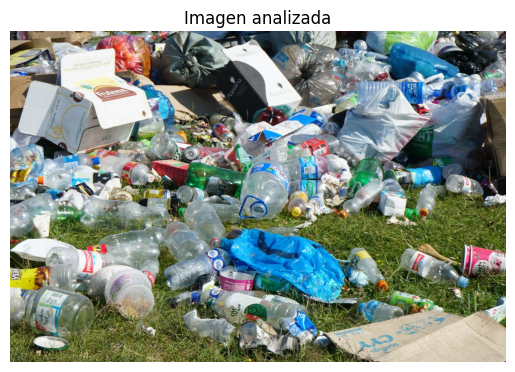

In [41]:
LABELS_ES = {

    "cardboard": "Cartón",

    "glass": "Vidrio",

    "metal": "Metal",

    "paper": "Papel",

    "plastic": "Plástico",

    "trash": "Basura",

}



def predict_image(img_path_param):

    img = Image.open(img_path_param).convert("RGB").resize(IMG_SIZE)

    arr = np.array(img, dtype=np.float32) / 255.0

    arr = np.expand_dims(arr, axis=0)

    preds = model.predict(arr, verbose=0)[0]

    top3_idx = np.argsort(preds)[-3:][::-1]

    for idx in top3_idx:

        raw = class_names[idx]

        print(f"{LABELS_ES.get(raw, raw)}: {preds[idx]*100:.2f}%")

    return class_names[np.argmax(preds)]

# Ejemplo:

example_img_path = "desechos.png"

predict_image(example_img_path)

plt.imshow(Image.open(example_img_path)); plt.title("Imagen analizada"); plt.axis("off")